working of random forest

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y = make_classification(n_features=5, n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.428041,-0.555722,0.306665,1.458470,-1.777203,1
1,1.507304,-0.017837,0.630110,1.255076,-1.976122,0
2,3.083900,1.387393,2.836813,-0.525295,-1.714652,0
3,1.528227,2.093569,1.186101,0.404981,-2.589874,0
4,1.604914,-0.146942,0.645477,0.921585,-1.097212,1


In [4]:
#function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
#function for features sampling

def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  return df[cols]

In [6]:
#function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

Row sampling

In [7]:
df1 = sample_rows(df,0.2) # row sampling
print(df1.shape)
print(df1)


(20, 6)
        col1      col2      col3      col4      col5  target
1   1.507304 -0.017837  0.630110  1.255076 -1.976122       0
88  2.011519  3.919091  1.137573 -2.195744 -2.134832       0
19  1.439090 -1.061993  2.471143  2.045635 -1.293449       1
40  1.706150  3.305409  1.369215 -2.165596 -1.613534       0
61  2.824439 -0.335041  1.735834  1.756532 -0.564313       0
69 -0.675186  2.667697 -0.645711 -2.159956 -1.694596       1
62  0.943311 -2.194653  1.610240  2.333309 -0.175565       1
65 -0.655827  1.309060 -0.103206 -1.821644 -0.258772       0
16  0.088183  0.648830 -0.069986 -0.330226 -0.598305       0
28  1.666442  3.300228  0.549943 -1.854246 -1.533591       0
0   1.428041 -0.555722  0.306665  1.458470 -1.777203       1
37  1.020236 -1.803975  0.161201  1.336918 -1.332630       1
58 -0.561247  3.444084  0.486347 -4.425562 -1.923155       0
18  2.393263  0.795341  1.478851  0.396210 -1.433789       0
16  0.088183  0.648830 -0.069986 -0.330226 -0.598305       0
98  1.700601 -1.

In [8]:
df2 = sample_rows(df,0.2)   # row sampling
print(df2.shape)
print(df2)

(20, 6)
        col1      col2      col3      col4      col5  target
88  2.011519  3.919091  1.137573 -2.195744 -2.134832       0
7   3.223870 -0.185919 -0.455170  2.375605  0.364221       1
55  0.394489  0.637634  2.425178 -3.283366 -0.870203       0
24 -0.344837 -2.065865  2.532130  0.441378 -0.371574       1
16  0.088183  0.648830 -0.069986 -0.330226 -0.598305       0
71  1.395720 -0.755296  0.707838  1.003833  0.721062       1
24 -0.344837 -2.065865  2.532130  0.441378 -0.371574       1
91  1.433708  0.989310  1.240230  0.383133 -1.643336       1
95  1.412579  3.149549  0.508389 -2.421909 -0.992296       0
0   1.428041 -0.555722  0.306665  1.458470 -1.777203       1
4   1.604914 -0.146942  0.645477  0.921585 -1.097212       1
57  1.199399  2.095746  0.962708 -0.101963 -2.759530       0
77  1.328307  0.851055  1.360217 -0.690067 -0.776913       0
12  0.737954 -2.206217  2.362358  0.948809 -0.970817       1
83  0.004746 -0.505590 -0.191447 -1.111450  0.210763       0
70  1.621960  1.

In [9]:
df3 = sample_rows(df,0.2) # row sampling
print(df3.shape)
print(df3)

(20, 6)
        col1      col2      col3      col4      col5  target
5   0.232399 -0.042972  0.103377 -0.520632 -0.341501       0
95  1.412579  3.149549  0.508389 -2.421909 -0.992296       0
51  1.494679  1.204920  1.227392 -1.236353 -0.548082       0
95  1.412579  3.149549  0.508389 -2.421909 -0.992296       0
83  0.004746 -0.505590 -0.191447 -1.111450  0.210763       0
0   1.428041 -0.555722  0.306665  1.458470 -1.777203       1
28  1.666442  3.300228  0.549943 -1.854246 -1.533591       0
74 -0.144592  2.419652  0.392414 -2.110740 -1.463416       0
14  1.391298 -0.567019 -0.470001  1.187840  1.785163       1
45  2.756469  0.484583 -0.093278  1.375792 -0.947931       1
85  2.380402  1.048244  0.739298  0.898643  1.237807       1
5   0.232399 -0.042972  0.103377 -0.520632 -0.341501       0
40  1.706150  3.305409  1.369215 -2.165596 -1.613534       0
57  1.199399  2.095746  0.962708 -0.101963 -2.759530       0
91  1.433708  0.989310  1.240230  0.383133 -1.643336       1
62  0.943311 -2.

In [10]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [11]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])


DecisionTreeClassifier()

In [12]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[3] <= 0.141\ngini = 0.48\nsamples = 20\nvalue = [12, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]')]

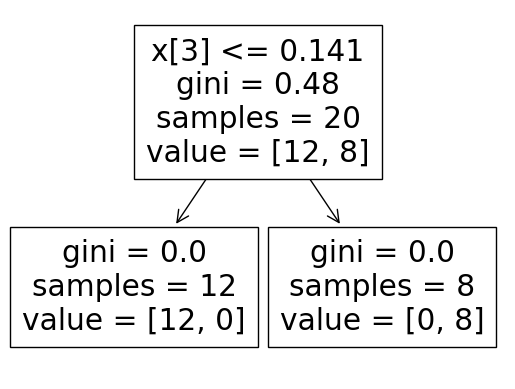

In [13]:
#plot_tree(clf1)
#plot_tree(clf2)
plot_tree(clf3)

In [14]:
#for row sampling
#clf1.predict(np.array([1.050390,  0.842886,  0.808876, -2.598329, -0.029897]).reshape(1,5))
#clf2.predict(np.array([1.050390,  0.842886,  0.808876, -2.598329, -0.029897]).reshape(1,5))
clf3.predict(np.array([1.050390,  0.842886,  0.808876, -2.598329, -0.029897]).reshape(1,5))

c:\Users\KAVANA\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

feature sampling

In [15]:
df1 = sample_features(df,0.8)  # column or feature sampling

In [16]:
df2 = sample_features(df,0.8)  # column or feature sampling

In [17]:
df3 = sample_features(df,0.8)  # column or feature sampling

In [18]:
#for features sampling or column sampling
print(df1.columns)
# print(df2.columns)
# print(df3.columns)

Index(['col5', 'col2', 'col4', 'col3'], dtype='object')


In [19]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [20]:
#for features_sampling change 0:4
clf1.fit(df1,df['target'])
clf2.fit(df2,df['target'])
clf3.fit(df3,df['target'])

DecisionTreeClassifier()

In [21]:
from sklearn.tree import plot_tree

[Text(0.46938775510204084, 0.9444444444444444, 'x[1] <= -0.053\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.12244897959183673, 0.8333333333333334, 'x[1] <= -0.989\ngini = 0.227\nsamples = 46\nvalue = [6, 40]'),
 Text(0.08163265306122448, 0.7222222222222222, 'gini = 0.0\nsamples = 25\nvalue = [0, 25]'),
 Text(0.16326530612244897, 0.7222222222222222, 'x[1] <= -0.704\ngini = 0.408\nsamples = 21\nvalue = [6, 15]'),
 Text(0.08163265306122448, 0.6111111111111112, 'x[3] <= 0.676\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.04081632653061224, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.12244897959183673, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.24489795918367346, 0.6111111111111112, 'x[0] <= 0.198\ngini = 0.219\nsamples = 16\nvalue = [2, 14]'),
 Text(0.20408163265306123, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2857142857142857, 0.5, 'x[0] <= 2.414\ngini = 0.124\nsamples = 15\nvalue = [1, 14]'),
 Text(0.24489795918367346, 0.388888

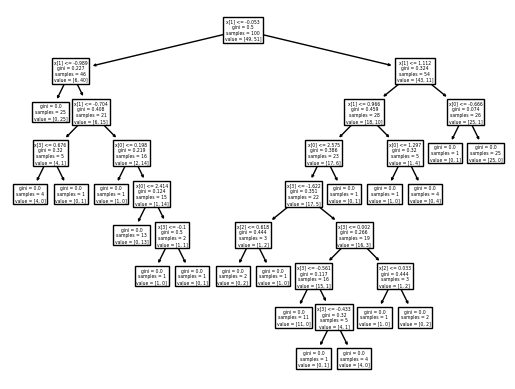

In [22]:
#plot_tree(clf1)
#plot_tree(clf2)
plot_tree(clf3)

In [23]:
#for feature sampling
clf1.predict(np.array([1.050390,  0.842886,  0.808876, -2.598329]).reshape(1,4))
# clf2.predict(np.array([1.050390,  0.842886,  0.808876, -2.598329]).reshape(1,4))
# clf3.predict(np.array([1.050390,  0.842886,  0.808876, -2.598329]).reshape(1,4))

c:\Users\KAVANA\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

combined sampling

In [24]:
df1 = combined_sampling(df,0.5,0.5) # combined sampling

In [25]:
df2 = combined_sampling(df,0.5,0.5) # combined sampling

In [26]:
df3 = combined_sampling(df,0.5,0.5) # combined sampling

In [27]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [28]:
# for combined_sampling, use the original 'target' column indexed by sampled rows
clf1.fit(df1, df.loc[df1.index, 'target'])
clf2.fit(df2, df.loc[df2.index, 'target'])
clf3.fit(df3, df.loc[df3.index, 'target'])

DecisionTreeClassifier()

In [29]:
from sklearn.tree import plot_tree

[Text(0.5, 0.9, 'x[1] <= 0.007\ngini = 0.487\nsamples = 50\nvalue = [21, 29]'),
 Text(0.23076923076923078, 0.7, 'x[1] <= -0.989\ngini = 0.236\nsamples = 22\nvalue = [3, 19]'),
 Text(0.15384615384615385, 0.5, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.3076923076923077, 0.5, 'x[1] <= -0.663\ngini = 0.397\nsamples = 11\nvalue = [3, 8]'),
 Text(0.15384615384615385, 0.3, 'x[0] <= 0.705\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.07692307692307693, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.23076923076923078, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.46153846153846156, 0.3, 'x[0] <= 1.331\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.38461538461538464, 0.1, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.5384615384615384, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7692307692307693, 0.7, 'x[0] <= -0.205\ngini = 0.459\nsamples = 28\nvalue = [18, 10]'),
 Text(0.6923076923076923, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [0

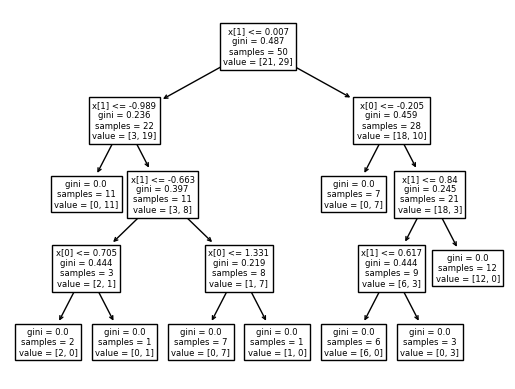

In [30]:
#plot_tree(clf1)
#plot_tree(clf2)
plot_tree(clf3)

In [31]:
#for combined_sampling
clf1.predict(np.array([1.050390,  0.842886]).reshape(1,2))
# clf2.predict(np.array([1.050390,  0.842886]).reshape(1,2))
# clf3.predict(np.array([1.050390,  0.842886]).reshape(1,2))

c:\Users\KAVANA\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

## Example 1

In [32]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initialize the Random Forest Classifier
# n_estimators is the number of trees in the forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

#Train the model
model.fit(X_train, y_train)

#Make predictions
y_pred = model.predict(X_test)

#Evaluate the results
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Example 2

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

titanic_data = pd.read_csv('titanic.csv')

titanic_data = titanic_data.dropna(subset=['Survived'])

X = titanic_data[['Pclass','Sex','Age','SibSp','Parch','Fare']]
y = titanic_data['Survived']

X['Sex'] = X['Sex'].map({'female':0,'male':1})
X['Age'] = X['Age'].fillna(X['Age'].median())

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100,random_state=42)
rf_classifier.fit(X_train,y_train)

y_pred = rf_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

FileNotFoundError: [Errno 2] No such file or directory: 'titanic.csv'